# **Convex Optimization Project 4**
Name: Reza Kahidi\
Student Number: 810101249

In [2]:
import cvxpy as cp
import numpy as np
from matplotlib import pyplot as plt

##Data

In [3]:
# Define the data
pmf1 = np.array([0.0057432 , 0.00568681, 0.00563071, 0.00557498, 0.00551972,
                    0.00546506, 0.00541118, 0.00535827, 0.00530658, 0.00525643,
                    0.00520818, 0.00516228, 0.00511926, 0.00507976, 0.00504453,
                    0.00501442, 0.00499046, 0.00497379, 0.00496576, 0.00496784,
                    0.00498171, 0.00500924, 0.00505245, 0.00511357, 0.00519497,
                    0.00529917, 0.00542882, 0.00558664, 0.00577539, 0.0059978 ,
                    0.00625655, 0.00655413, 0.00689281, 0.00727454, 0.00770087,
                    0.00817282, 0.00869081, 0.00925459, 0.00986312, 0.01051451,
                    0.01120597, 0.01193374, 0.01269312, 0.01347842, 0.014283  ,
                    0.01509936, 0.01591918, 0.01673347, 0.01753268, 0.01830687,
                    0.01904591, 0.01973967, 0.02037822, 0.02095206, 0.02145234,
                    0.02187105, 0.02220122, 0.02243708, 0.02257424, 0.02260972,
                    0.02254213, 0.02237163, 0.02209992, 0.02173028, 0.02126737,
                    0.02071723, 0.02008705, 0.01938501, 0.01862012, 0.01780197,
                    0.01694056, 0.01604604, 0.01512851, 0.01419784, 0.01326348,
                    0.01233431, 0.01141849, 0.01052335, 0.00965535, 0.00881997,
                    0.00802173, 0.0072642 , 0.00654997, 0.00588076, 0.00525746,
                    0.00468016, 0.00414833, 0.00366082, 0.003216  , 0.00281186,
                    0.00244606, 0.00211607, 0.00181921, 0.00155272, 0.00131385,
                    0.00109989, 0.00090822, 0.00073634, 0.00058192, 0.00044276])
pmf2 = np.array([0.00632314, 0.00827662, 0.01006408, 0.01169326, 0.01317164,
                    0.01450654, 0.01570504, 0.01677402, 0.01772018, 0.01854998,
                    0.01926973, 0.01988551, 0.02040323, 0.0208286 , 0.02116715,
                    0.02142423, 0.02160501, 0.02171447, 0.02175744, 0.02173855,
                    0.02166229, 0.02153297, 0.02135473, 0.02113155, 0.02086728,
                    0.02056558, 0.02022997, 0.01986384, 0.0194704 , 0.01905275,
                    0.01861381, 0.01815641, 0.0176832 , 0.01719673, 0.01669939,
                    0.01619347, 0.01568113, 0.0151644 , 0.01464519, 0.01412531,
                    0.01360644, 0.01309015, 0.01257791, 0.01207109, 0.01157095,
                    0.01107865, 0.01059526, 0.01012174, 0.00965899, 0.00920778,
                    0.00876883, 0.00834276, 0.00793012, 0.00753138, 0.00714692,
                    0.00677707, 0.00642209, 0.00608215, 0.00575739, 0.00544786,
                    0.00515357, 0.00487448, 0.00461047, 0.00436141, 0.00412709,
                    0.00390727, 0.00370167, 0.00350996, 0.0033318 , 0.00316679,
                    0.00301452, 0.00287453, 0.00274636, 0.00262952, 0.00252349,
                    0.00242775, 0.00234176, 0.00226497, 0.00219681, 0.00213673,
                    0.00208417, 0.00203854, 0.0019993 , 0.00196589, 0.00193775,
                    0.00191437, 0.0018952 , 0.00187976, 0.00186756, 0.00185813,
                    0.00185105, 0.0018459 , 0.00184231, 0.00183994, 0.00183848,
                    0.00183767, 0.00183728, 0.00183713, 0.0018371 , 0.0018371 ])
pmf3 = np.array([0.00189586, 0.00222167, 0.00257546, 0.00295857, 0.0033721 ,
                    0.00381692, 0.00429358, 0.00480228, 0.00534286, 0.00591468,
                    0.00651666, 0.00714717, 0.00780411, 0.00848478, 0.00918597,
                    0.0099039 , 0.01063429, 0.01137236, 0.01211288, 0.01285024,
                    0.01357851, 0.01429152, 0.01498295, 0.01564645, 0.01627572,
                    0.01686462, 0.01740729, 0.01789828, 0.01833258, 0.01870581,
                    0.01901425, 0.01925492, 0.01942565, 0.01952512, 0.0195529 ,
                    0.01950944, 0.01939607, 0.01921497, 0.01896914, 0.0186623 ,
                    0.01829887, 0.01788385, 0.01742271, 0.01692134, 0.01638587,
                    0.01582263, 0.01523799, 0.01463826, 0.01402965, 0.01341809,
                    0.0128092 , 0.01220824, 0.01161999, 0.01104875, 0.01049831,
                    0.00997191, 0.00947224, 0.00900144, 0.00856113, 0.00815242,
                    0.00777595, 0.00743191, 0.00712012, 0.00684001, 0.00659076,
                    0.00637126, 0.0061802 , 0.00601612, 0.00587744, 0.00576248,
                    0.00566955, 0.00559694, 0.00554294, 0.00550591, 0.00548425,
                    0.00547644, 0.00548106, 0.00549677, 0.00552234, 0.00555664,
                    0.00559865, 0.00564743, 0.00570218, 0.00576214, 0.00582668,
                    0.00589523, 0.00596729, 0.00604245, 0.00612035, 0.00620067,
                    0.00628316, 0.0063676 , 0.00645382, 0.00654166, 0.00663102,
                    0.00672179, 0.00681391, 0.00690732, 0.00700197, 0.00709783])
pmf4 = np.array([0.00151817, 0.00165627, 0.00179441, 0.0019326 , 0.00207083,
                    0.00220913, 0.00234751, 0.00248598, 0.00262457, 0.00276329,
                    0.00290218, 0.00304126, 0.00318058, 0.00332018, 0.0034601 ,
                    0.00360041, 0.00374117, 0.00388246, 0.00402437, 0.00416698,
                    0.00431041, 0.00445477, 0.00460021, 0.00474688, 0.00489492,
                    0.00504453, 0.0051959 , 0.00534922, 0.00550473, 0.00566267,
                    0.00582328, 0.00598682, 0.00615356, 0.00632378, 0.00649778,
                    0.00667582, 0.00685819, 0.00704517, 0.00723701, 0.00743398,
                    0.00763629, 0.00784413, 0.00805768, 0.00827706, 0.00850234,
                    0.00873355, 0.00897064, 0.00921354, 0.00946206, 0.00971597,
                    0.00997494, 0.0102386 , 0.01050645, 0.01077795, 0.01105246,
                    0.01132927, 0.0116076 , 0.0118866 , 0.01216536, 0.01244292,
                    0.0127183 , 0.01299046, 0.01325836, 0.01352095, 0.0137772 ,
                    0.0140261 , 0.01426667, 0.014498  , 0.01471923, 0.01492958,
                    0.01512838, 0.01531505, 0.01548911, 0.01565021, 0.01579814,
                    0.01593279, 0.01605419, 0.01616251, 0.01625804, 0.01634118,
                    0.01641246, 0.01647252, 0.01652207, 0.01656195, 0.01659304,
                    0.01661628, 0.01663266, 0.01664323, 0.01664901, 0.01665105,
                    0.01665039, 0.01664804, 0.01664499, 0.01664215, 0.01664042,
                    0.01664061, 0.01664346, 0.01664964, 0.01665976, 0.01667433])
P = np.stack([pmf1, pmf2,
              pmf3, pmf4], axis=0).T


def plot_pmfs():
    plt.figure()
    plt.plot(pmf1, label='distribution_1')
    plt.plot(pmf2, label='distribution_2')
    plt.plot(pmf3, label='distribution_3')
    plt.plot(pmf4, label='distribution_4')
    plt.legend()
    plt.show()

def plot_stackplot(detector, title="Detector"):
    """
    Takes in an mxn detector matrix and plots a stackplot of the detector
    """
    plt.figure()
    plt.stackplot(np.arange(pmf1.size), detector, labels=['distribution_1',
                                                          'distribution_2',
                                                          'distribution_3',
                                                          'distribution_4'])
    plt.legend()
    plt.title(title)
    plt.show()

## Problem

Plot Distributions

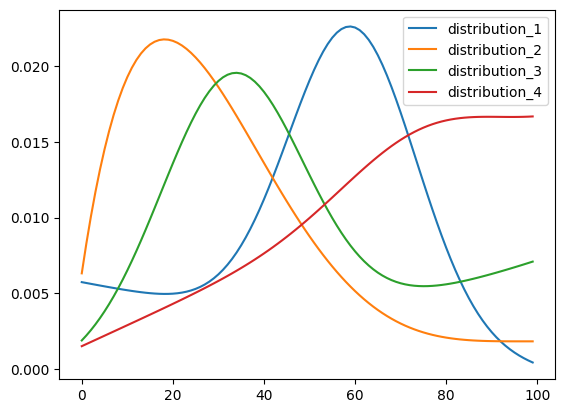

In [4]:
plot_pmfs()

Part a

In [5]:
n, m = P.shape
T = cp.Variable((m, n))
D = T @ P

E = []
for i in range(m):
  for j in range(m):
    if i != j :
      E.append(D[i, j])

obj1 = cp.Minimize(cp.max(cp.hstack(E)))
const1 = [T >= 0, cp.sum(T, axis=0) == 1]
prob1 = cp.Problem(obj1, const1)
prob1.solve()

print("Problem Status :", prob1.status)
print("Optimal value =", prob1.value)
D_s = T.value @ P
print("D* =", D_s)


Problem Status : optimal
Optimal value = 0.22506022983017157
D* = [[0.3309195  0.22143077 0.22506023 0.22307849]
 [0.22175464 0.33850283 0.22506023 0.21226344]
 [0.22506023 0.22506023 0.32481927 0.22506023]
 [0.22226562 0.2150061  0.22506023 0.33959784]]


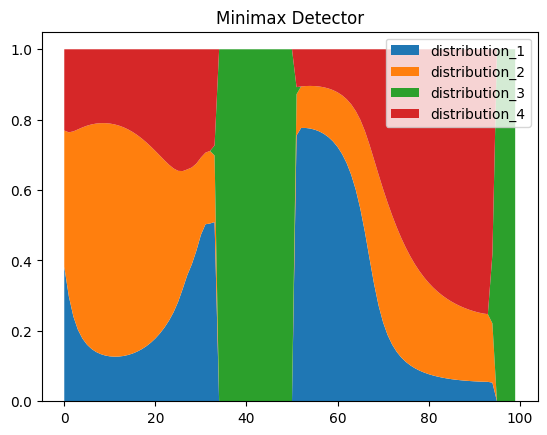

In [6]:
plot_stackplot(T.value, title="Minimax Detector")

Part b

In [7]:
n, m = P.shape
T = cp.Variable((m, n))
D = T @ P

obj2 = cp.Maximize(cp.min(cp.diag(D)))
const2 = [T >= 0, cp.sum(T, axis=0) == 1]
prob2 = cp.Problem(obj2, const2)
prob2.solve()

print("Problem Status :", prob2.status)
print("Optimal value =", prob2.value)
D_s = T.value @ P
print("D* =", D_s)


Problem Status : optimal
Optimal value = 0.4498518187880712
D* = [[0.44985182 0.11270395 0.17553106 0.28447415]
 [0.13101786 0.44985182 0.20857567 0.07990737]
 [0.26912836 0.38211985 0.44985182 0.18576665]
 [0.15000195 0.05532432 0.1660414  0.44985182]]


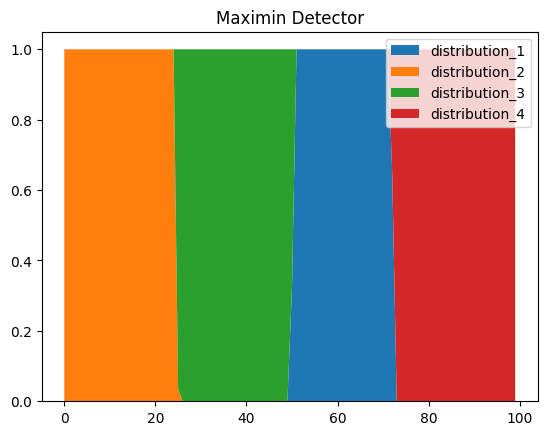

In [8]:
plot_stackplot(T.value, title="Maximin Detector")

Part c

In [9]:
n, m = P.shape
T = cp.Variable((m, n))
D = T @ P

E = []
for i in range(m):
  for j in range(m):
    if i != j :
      E.append(D[i, j])

obj1 = cp.Minimize((1/(m**2 - m)) * cp.sum(cp.hstack(E)))
const1 = [T >= 0, cp.sum(T, axis=0) == 1]
prob1 = cp.Problem(obj1, const1)
prob1.solve()

print("Problem Status :", prob1.status)
print("Optimal value =", prob1.value)
D_s = T.value @ P
print("D* =", D_s)


Problem Status : optimal
Optimal value = 0.18126107028327387
D* = [[0.52136301 0.1564239  0.23790036 0.31849264]
 [0.15891898 0.54830977 0.29719007 0.10648669]
 [0.15986836 0.23815423 0.29526003 0.11508644]
 [0.15984963 0.05711202 0.1696495  0.45993422]]


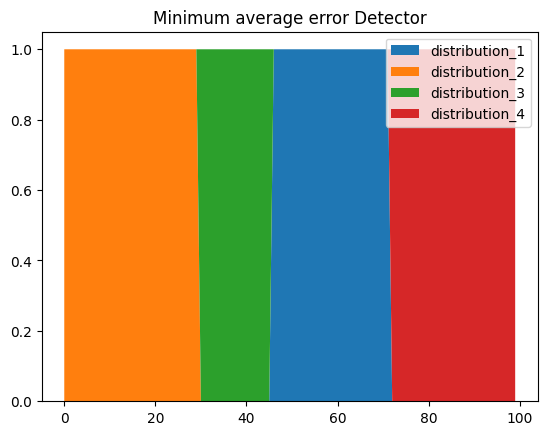

In [10]:
plot_stackplot(T.value, title="Minimum average error Detector")